In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from scipy.stats import norm
import pytensor.tensor as pt
import arviz as az
from matplotlib.ticker import MultipleLocator

In [2]:
file_path = "csv-files/zro2_white&green_ 50_days.csv"
data = pd.read_csv(file_path, header=None)
spectrum_50 = data[0].values
t_50 = 4279386 # 50 days exposure
a_50 = 0.357304
b_50 = -0.295444
c_50  = 1.352297E-009
E_kev =  np.arange(len(spectrum_50)) * a_50 + b_50 + c_50 * np.arange(len(spectrum_50))**2
mask = (E_kev>=0) & (E_kev <= 3000)
E_kev = E_kev[mask]
spectrum_50 = spectrum_50[mask]
spectrum_50_norm = spectrum_50/t_50

In [3]:
file_path = "csv-files/bkg.csv"
data = pd.read_csv(file_path, header=None)
spectrum_bkg = data[0].values
t_bkg = 4143234 # 40 days exposure
spectrum_bkg = spectrum_bkg[mask]
spectrum_bkg_norm = spectrum_bkg  / t_bkg

In [4]:
def sigma_fun(E):
    A = 3.68436e1
    B = 1.72714e4
    return (E * np.sqrt(A/E + B/E**2)) / 2.355/100

In [5]:
mu_signal = 778
sigma_signal = sigma_fun(mu_signal)

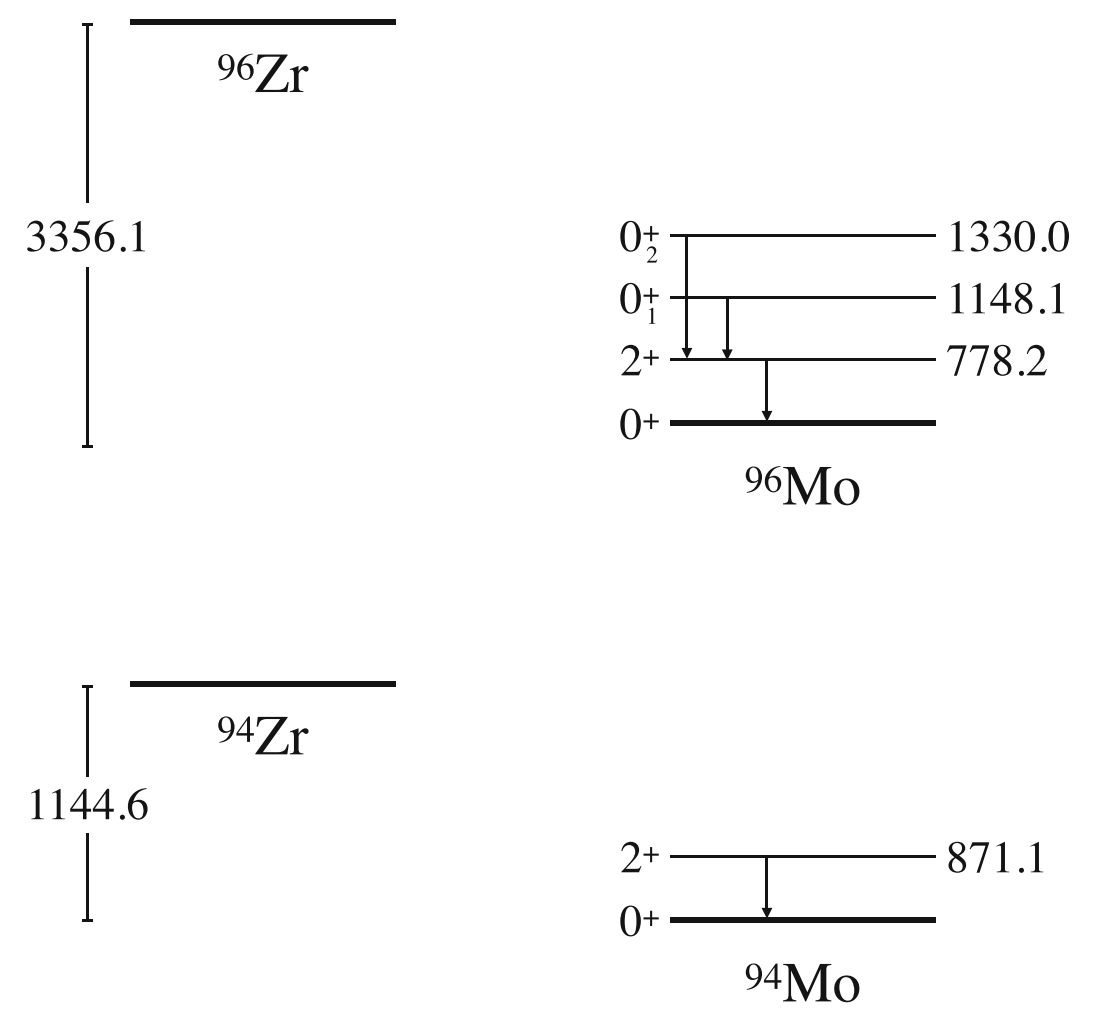


In [6]:
bb_peaks = np.sort([551.8, 369.9, 778.2])

In [7]:
ROIs = [[335,385],
        [515,575],
        [730,790]]

/tmp/ipykernel_133592/376275306.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


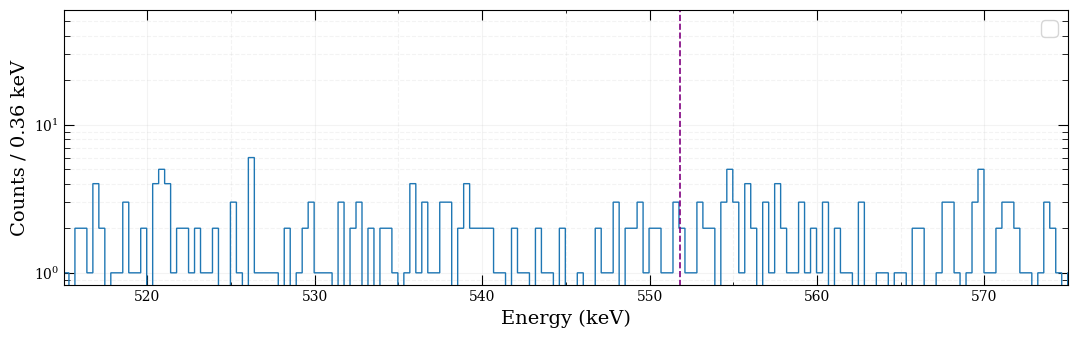

In [8]:

# Stile da paper (EPJ-like)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (11, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

plt.figure()
ax = plt.gca()


dx_major = 10
dx_minor = 5

ax.xaxis.set_major_locator(MultipleLocator(dx_major))
ax.xaxis.set_minor_locator(MultipleLocator(dx_minor))
dy_major = 100
dy_minor = 20

ax.yaxis.set_major_locator(MultipleLocator(dy_major))

ax.tick_params(axis='x', which='major', length=7, labelsize=10)
#ax.tick_params(axis='x', which='minor', length=4)

ax.tick_params(axis='y', which='major', length=7, labelsize=10)
ax.tick_params(axis='y', which='minor', length=4)

# Bin width

#bins = np.linspace(min(E_kev), max(E_kev), int(len(E_kev)/56))
bins = np.linspace(min(E_kev), max(E_kev), int(len(E_kev)))
counts, bin_edge, _ = plt.hist(E_kev, bins = bins, weights = spectrum_50,   
                               histtype='step',
                               )
db = bin_edge[1]- bin_edge[0]



plt.xlabel('Energy (keV)')
plt.ylabel(rf'Counts / {db:.2f} keV')
#plt.xlim(300, 900)
plt.xlim(ROIs[1])
plt.yscale('log')
plt.grid(alpha=0.15)
ax.grid(which='major', linestyle='-', alpha=0.15)
ax.grid(which='minor', linestyle='--', alpha=0.15)
plt.tight_layout()
plt.legend(fontsize=15)

peak = 778
d = 200
plt.vlines([bb_peaks[2]], ymin=1e-3, ymax=1e3, color='purple', linestyle='--') 
plt.vlines([bb_peaks[0]], ymin=1e-3, ymax=1e3, color='purple', linestyle='--') 
plt.vlines([bb_peaks[1]], ymin=1e-3, ymax=1e3, color='purple', linestyle='--') 
plt.vlines([328.3], ymin=1e-3, ymax=1e3, colors="green")  # AC-228
plt.vlines([341], ymin=1e-3, ymax=1e3, colors="green")  # 228-Ac
plt.vlines([351], ymin=1e-3, ymax=1e3, color='red', linestyle='--') #Bi-211
plt.vlines([511], ymin=1e-3, ymax=1e3, color='red', linestyle='--') #ann
plt.vlines([583], ymin=1e-3, ymax=1e3, color='red', linestyle='--') #Tl-208
plt.vlines([765], ymin=1e-3, ymax=1e3, color='red', linestyle='--') #Tl-208
#plt.xlim(bb_peaks[0] - d, bb_peaks[0] + d)
plt.savefig("spectrum_50_days.png")
plt.show()

--------

# Energy resolution

In [9]:
def sigma_fun(E):
    A = 3.68436e1
    B = 1.72714e4
    return (E * np.sqrt(A/E + B/E**2)) / 2.355/100

----------

# Picco 0

In [10]:
def fit_double_gaussian_poisson_plot(E, N, center1, center2, de):
    """
    Fit di due gaussiane + fondo lineare con likelihood di Poisson.
    Le due gaussiane condividono la stessa sigma.

    Produce:
      1) Istogramma + fit
      2) Profile likelihood ΔNLL per tutti i parametri con ±1σ interpolati

    Restituisce:
      fit_values, err_minus_all, err_plus_all, result
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.optimize import minimize

    # ==========================
    # Bin
    # ==========================
    bins = np.linspace(min(E), max(E), int(len(E)) + 1)
    db = bins[1] - bins[0]

    counts, edges = np.histogram(E, bins=bins, weights=N)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])

    # ==========================
    # ROI
    # ==========================
    roi = (min(center1, center2) - de,
           max(center1, center2) + de)

    mask = (E >= roi[0]) & (E <= roi[1])

    counts_roi = N[mask]
    centers_roi = E[mask]

    # ==========================
    # Modello:
    # doppia gaussiana con sigma comune
    # ==========================
    def model(params, x):

        A1, A2, mu1, mu2, sigma,  B = params

        G1 = (
            A1
            * (1 / (sigma * np.sqrt(2 * np.pi)))
            * np.exp(-(x - mu1) ** 2 / (2 * sigma ** 2))
        )

        G2 = (
            A2
            * (1 / (sigma * np.sqrt(2 * np.pi)))
            * np.exp(-(x - mu2) ** 2 / (2 * sigma ** 2))
        )

        #background = M * x + B
        background = + B

        return G1 + G2 + background

    # ==========================
    # Negative log-likelihood Poisson
    # ==========================
    def nll(params):

        lam = model(params, centers_roi)
        lam = np.clip(lam, 1e-12, None)

        return np.sum(lam - counts_roi * np.log(lam))

    # ==========================
    # Stime iniziali
    # ==========================
    total_counts = np.sum(counts_roi)

    A10 = total_counts / 2
    A20 = total_counts / 2

    mu10 = center1
    mu20 = center2

    sigma0 = sigma_fun((center1 + center2) / 2)

    #M0 = 0.0
    B0 = max(np.min(counts_roi), 1e-3)

    initial = [
        A10,
        A20,
        mu10,
        mu20,
        sigma0,
       # M0,
        B0,
    ]

    bounds = [
        (A10*0.99, A10*1.01),          # A1
        (A20*0.99, A20*1.01),          # A2
        (roi[0], roi[1]),   # mu1
        (roi[0], roi[1]),   # mu2
        (1e-5, 100),        # sigma comune
        #(-10, None),        # M
        (1e-7, None),       # B
    ]

    # ==========================
    # Minimizzazione
    # ==========================
    result = minimize(
        nll,
        initial,
        bounds=bounds,
        method="L-BFGS-B"
    )

    fit_values = result.x

    param_names = [
        'A1',
        'A2',
        'mu1',
        'mu2',
        'sigma',
        'M',
        'B'
    ]

    print("\nBest fit:")
    for n, v in zip(param_names, fit_values):
        print(f"{n} = {v:.5f}")

    # ==========================
    # Plot fit
    # ==========================
    fig, ax = plt.subplots(figsize=(6, 4))

    plt.hist(
        E,
        bins=bins,
        weights=N,
        color='tab:gray',
        histtype='step',
        label='Data'
    )

    plt.scatter(
        centers_roi,
        counts_roi,
        color='black',
        s=12
    )

    x_plot = np.linspace(roi[0], roi[1], 2000)

    y_plot = model(fit_values, x_plot)

    plt.plot(
        x_plot,
        y_plot,
        color='deepskyblue',
        lw=2,
        label='Total fit'
    )

    # componenti separate
    #A1, A2, mu1, mu2, sigma, M, B = fit_values
    A1, A2, mu1, mu2, sigma, B = fit_values

    G1 = (
        A1
        * (1 / (sigma * np.sqrt(2 * np.pi)))
        * np.exp(-(x_plot - mu1) ** 2 / (2 * sigma ** 2))
    )

    G2 = (
        A2
        * (1 / (sigma * np.sqrt(2 * np.pi)))
        * np.exp(-(x_plot - mu2) ** 2 / (2 * sigma ** 2))
    )

    BG =  B

    plt.plot(x_plot, G1, '--', label='Gaussian 1')
    plt.plot(x_plot, G2, '--', label='Gaussian 2')
    #plt.plot(x_plot, BG, ':', label='Background')

    plt.axvline(mu1, ls='--', alpha=0.6)
    plt.axvline(mu2, ls='--', alpha=0.6)

    plt.xlim(roi)

    plt.xlabel("Energy (keV)", size=13)
    plt.ylabel(f"Counts / {db:.3f} keV", size=13)

    plt.grid(alpha=0.2)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # ==========================
    # PROFILE LIKELIHOOD
    # ==========================
    scans = []
    delta_nlls = []

    err_minus_all = []
    err_plus_all = []

    nll_min = nll(fit_values)

    for i, pname in enumerate(param_names):

        val_fit = fit_values[i]

        # range scans
        if "A" in pname:
            scan = np.linspace(
                max(1e-3, val_fit * 0.2),
                val_fit * 2,
                60
            )

        elif "mu" in pname:
            scan = np.linspace(
                val_fit - 3 * sigma,
                val_fit + 3 * sigma,
                60
            )

        elif pname == "sigma":
            scan = np.linspace(
                val_fit * 0.3,
                val_fit * 2,
                60
            )

        else:
            scan = np.linspace(
                val_fit - abs(val_fit) * 2 - 1,
                val_fit + abs(val_fit) * 2 + 1,
                60
            )

        delta_nll = []

        for x_val in scan:

            def nll_profile(other_params):

                full = fit_values.copy()

                cnt = 0

                for j in range(len(fit_values)):

                    if j == i:
                        full[j] = x_val

                    else:
                        full[j] = other_params[cnt]
                        cnt += 1

                return nll(full)

            other_initial = [
                fit_values[j]
                for j in range(len(fit_values))
                if j != i
            ]

            other_bounds = [
                bounds[j]
                for j in range(len(fit_values))
                if j != i
            ]

            res2 = minimize(
                nll_profile,
                other_initial,
                bounds=other_bounds,
                method="L-BFGS-B"
            )

            delta_nll.append(res2.fun - nll_min)

        delta_nll = np.array(delta_nll)

        scans.append(scan)
        delta_nlls.append(delta_nll)

        # ==========================
        # Errori 1σ
        # ==========================
        scan_left = scan[scan < val_fit]
        delta_left = delta_nll[scan < val_fit]

        if np.any(delta_left >= 0.5):

            err_minus = (
                val_fit
                - np.interp(
                    0.5,
                    delta_left[::-1],
                    scan_left[::-1]
                )
            )

        else:
            err_minus = np.nan

        scan_right = scan[scan > val_fit]
        delta_right = delta_nll[scan > val_fit]

        if np.any(delta_right >= 0.5):

            err_plus = (
                np.interp(
                    0.5,
                    delta_right,
                    scan_right
                )
                - val_fit
            )

        else:
            err_plus = np.nan

        err_minus_all.append(err_minus)
        err_plus_all.append(err_plus)

        print(
            f"{pname} = "
            f"{val_fit:.5f}"
            f" -{err_minus:.5f}"
            f"/+{err_plus:.5f}"
        )

    # ==========================
    # Plot ΔNLL
    # ==========================
    npars = len(param_names)

    ncols = 2
    nrows = int(np.ceil(npars / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(8, 3 * nrows)
    )

    axes = np.array(axes).flatten()

    for i in range(npars):

        ax = axes[i]

        ax.plot(scans[i], delta_nlls[i])

        ax.axhline(0.5, color='red', ls='--')

        ax.axvline(fit_values[i], color='green', ls='--')

        if not np.isnan(err_minus_all[i]):
            ax.axvline(
                fit_values[i] - err_minus_all[i],
                color='orange',
                ls='--'
            )

        if not np.isnan(err_plus_all[i]):
            ax.axvline(
                fit_values[i] + err_plus_all[i],
                color='purple',
                ls='--'
            )

        ax.set_xlabel(param_names[i])
        ax.set_ylabel("ΔNLL")

        ax.grid(alpha=0.3)

    # subplot vuoti
    for j in range(npars, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return (
        fit_values,
        err_minus_all,
        err_plus_all,
        result
    )

In [11]:
spectrum_50[(E_kev >325) & (E_kev < 340)]

array([ 3,  4,  2,  7,  7,  5,  7,  5, 13, 16, 17, 16, 16, 27, 19, 12,  2,
        3,  3,  6,  3,  3,  1,  3,  4,  4,  5,  1,  4,  4,  0,  0,  3,  3,
        6,  6,  6,  5,  2,  5,  5,  2])

In [12]:


def fit_double_gaussian_poisson_plot(
    E,
    N,
    center1,
    center2,
    de,
    sigma_fixed=None
):

    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.optimize import minimize

    # =====================================================
    # BINNING
    # =====================================================
    bins = np.linspace(min(E), max(E), len(E) + 1)

    counts, edges = np.histogram(
        E,
        bins=bins,
        weights=N
    )

    bin_centers = 0.5 * (edges[:-1] + edges[1:])

    db = edges[1] - edges[0]

    # =====================================================
    # ROI
    # =====================================================
    roi = (
        min(center1, center2) - de,
        max(center1, center2) + de
    )

    mask_roi = (
        (bin_centers >= roi[0])
        &
        (bin_centers <= roi[1])
    )

    centers_roi = bin_centers[mask_roi]
    counts_roi = counts[mask_roi]

    # =====================================================
    # SIGMA FISSATA
    # =====================================================
    if sigma_fixed is None:
        sigma_fixed = sigma_fun((center1 + center2)/2)

    sigma = sigma_fixed

    # =====================================================
    # MODELLO
    # =====================================================
    # PARAMETRI:
    # A1, A2, mu1, mu2, B
    # =====================================================

    def model(params, x):

        A1, A2, mu1, mu2, B = params

        G1 = (
            A1
            /
            (sigma * np.sqrt(2*np.pi))
            *
            np.exp(-(x-mu1)**2/(2*sigma**2))
        )

        G2 = (
            A2
            /
            (sigma * np.sqrt(2*np.pi))
            *
            np.exp(-(x-mu2)**2/(2*sigma**2))
        )

        background = B

        # conteggi/bin
        return (G1 + G2 + background) * db

    # =====================================================
    # NLL POISSON
    # =====================================================
    def nll(params):

        A1, A2, mu1, mu2, B = params

        # evita scambio gaussiane
        if mu1 >= mu2:
            return 1e30

        lam = model(params, centers_roi)

        lam = np.clip(lam, 1e-12, None)

        return np.sum(
            lam - counts_roi*np.log(lam)
        )

    # =====================================================
    # STIME INIZIALI
    # =====================================================
    total_counts = np.sum(counts_roi)

    A10 = total_counts*0.2 
    A20 = total_counts *0.8

    B0 = np.median(counts_roi[:5])

    initial = [
        A10,
        A20,
        center1,
        center2,
        B0
    ]

    # =====================================================
    # BOUNDS
    # =====================================================
    bounds = [

        (total_counts*0.3, total_counts*0.4 ),
        (total_counts*0.5 , total_counts*10),

        (center1*0.999, center1*1.001),
        (center2*0.999, center2*1.001),

        (0, np.max(counts_roi))
    ]

    # =====================================================
    # FIT
    # =====================================================
    result = minimize(
        nll,
        initial,
        bounds=bounds,
        method='L-BFGS-B'
    )

    fit_values = result.x

    param_names = [
        'A1',
        'A2',
        'mu1',
        'mu2',
        'B'
    ]

    print('\n===== BEST FIT =====')

    for n, v in zip(param_names, fit_values):
        print(f'{n:5s} = {v:.5f}')

    print(f'sigma = {sigma:.5f} (fixed)')

    # =====================================================
    # PLOT FIT
    # =====================================================
    fig, ax = plt.subplots(figsize=(7,5))

    plt.hist(
        E,
        bins=bins,
        weights=N,
        histtype='step',
        lw=1.8,
        color='black',
        label='Data'
    )

    plt.errorbar(
        centers_roi,
        counts_roi,
        yerr=np.sqrt(np.clip(counts_roi,1,None)),
        fmt='o',
        ms=4,
        color='black'
    )

    x_plot = np.linspace(roi[0], roi[1], 3000)

    y_plot = model(fit_values, x_plot)

    plt.plot(
        x_plot,
        y_plot,
        color='deepskyblue',
        lw=2.5,
        label='Total fit'
    )

    A1, A2, mu1, mu2, B = fit_values

    G1 = (
        A1
        /
        (sigma*np.sqrt(2*np.pi))
        *
        np.exp(-(x_plot-mu1)**2/(2*sigma**2))
    ) * db

    G2 = (
        A2
        /
        (sigma*np.sqrt(2*np.pi))
        *
        np.exp(-(x_plot-mu2)**2/(2*sigma**2))
    ) * db

    BG = np.ones_like(x_plot) * B * db

    plt.plot(
        x_plot,
        G1 + BG,
        '--',
        lw=2,
        label='Gaussian 1'
    )

    plt.plot(
        x_plot,
        G2 + BG,
        '--',
        lw=2,
        label='Gaussian 2'
    )

    plt.plot(
        x_plot,
        BG ,
        ':',
        lw=2,
        label='Background'
    )

    plt.axvline(mu1, ls='--', alpha=0.6)
    plt.axvline(mu2, ls='--', alpha=0.6)

    plt.xlabel('Energy (keV)', fontsize=13)
    plt.ylabel(f'Counts / {db:.3f} keV', fontsize=13)

    plt.xlim(roi)

    ymax = max(counts_roi) * 1.4
    plt.ylim(0, ymax)

    plt.grid(alpha=0.2)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # =====================================================
    # HESSIAN ERRORS
    # =====================================================
    try:

        hess_inv = result.hess_inv.todense()

        errors = np.sqrt(np.diag(hess_inv))

    except:

        errors = np.full(len(fit_values), np.nan)

    print('\n===== ERRORS =====')

    for n, e in zip(param_names, errors):
        print(f'{n:5s} = ± {e:.5f}')

    return fit_values, errors, result




===== BEST FIT =====
A1    = 61.50000
A2    = 102.50000
mu1   = 329.07060
mu2   = 330.06960
B     = 9.09286
sigma = 0.72841 (fixed)


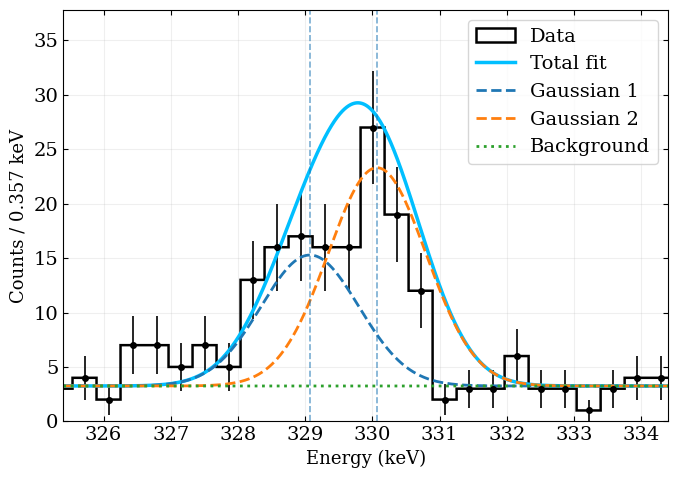


===== ERRORS =====
A1    = ± 1.00000
A2    = ± 49.89825
mu1   = ± 1.00000
mu2   = ± 1.00000
B     = ± 2.75534


In [13]:
fit_val, fit_err, res = fit_double_gaussian_poisson_plot(
    E_kev,
    spectrum_50,
    center1=329.4,
    center2=330.4,
    de=4
)

In [14]:
# FIT SINGOLO PICCO


In [15]:
def fit_gaussian_poisson_plot(E, N, center, de):
    """
    Fit gaussiana + fondo su Poisson usando i centri dei bin.
    Produce:
      1) Istogramma + fit
      2) Profile likelihood ΔNLL per tutti i parametri con ±1σ interpolati
    Restituisce: fit_values, err_minus_all, err_plus_all, result
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.optimize import minimize

    # ==========================
    # Bin identici al plot originale
    # ==========================
    bins = np.linspace(min(E), max(E), int(len(E))+1)
    db = bins[1]-bins[0]
    counts, edges = np.histogram(E, bins=bins, weights=N)
    bin_centers = 0.5*(edges[:-1]+edges[1:])
    #print(len(E), len(bin_centers), len(N))

    # ==========================
    # ROI
    # ==========================
    roi = (center-de, center+de)
    """
    mask = (bin_centers >= roi[0]) & (bin_centers <= roi[1])
    counts_roi = counts[mask]
    centers_roi = bin_centers[mask]"""
    mask = (E >= roi[0]) & (E <= roi[1])
    counts_roi = N[mask]
    centers_roi = E[mask]

    # ==========================
    # Modello classico sui centri
    # ==========================
    def model(params, x):
        A, mu, sigma,M, B = params
        return A * (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2*sigma**2)) + M*x +B

    # ==========================
    # NLL Poisson
    # ==========================
    def nll(params):
        lam = model(params, centers_roi)
        lam = np.clip(lam, 1e-12, None)
        return np.sum(lam - counts_roi*np.log(lam))

    # ==========================
    # Stime iniziali
    # ==========================
    A0 = np.sum(counts_roi)
    print(A0)
    mu0 = centers_roi[np.argmax(counts_roi)]
    sigma0 = sigma_fun(center)
    M0 = 0.0
    B0 = np.min(counts_roi)
    initial = [A0, mu0, sigma0, M0, B0]
    bounds = [(0,None),(roi[0],roi[1]),(1e-5,sigma0*1.1),(-10,10),(1e-7,None)]

    result = minimize(nll, initial, bounds=bounds, method="L-BFGS-B")
    fit_values = result.x
    param_names = ['A','mu','sigma','M','B']

    print("\nBest fit:")
    for n,v in zip(param_names, fit_values):
        print(f"{n} = {v:.3f}")

    # ==========================
    # PLOT ISTOGRAMMA + FIT
    # ==========================
    fig, ax = plt.subplots(figsize=(5,4))
    plt.hist(E, bins=bins, weights=N, color='tab:gray', histtype='step', label='50-days exposure')
    x_plot = np.linspace(roi[0], roi[1], 1000)
    y_plot = model(fit_values, x_plot)
    plt.scatter(centers_roi, counts_roi, color = 'black')
    plt.plot(x_plot, y_plot, color='deepskyblue', lw=2, label='Fit')
    plt.axvline(fit_values[1], color='deepskyblue', ls='--', label=f'μ = {fit_values[1]:.3f}')
    plt.xlim(roi)
    plt.hlines(fit_values[-1], min(roi), max(roi))
    plt.ylim(0, max(counts_roi)*1.5)
    plt.xlabel("Energy (keV)", size=13)
    plt.ylabel(f"Counts / {db:.1f} keV", size=13)
    plt.grid(alpha=0.13)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==========================
    # PROFILE LIKELIHOOD ΔNLL
    # ==========================
    scans, delta_nlls, err_minus_all, err_plus_all = [], [], [], []
    nll_min = nll(fit_values)

    for i, pname in enumerate(param_names):
        val_fit = fit_values[i]
        # definizione range scan
        if pname=='A':
            scan = np.linspace(val_fit*0.01, val_fit*2, 50)
        elif pname=='mu':
            scan = np.linspace(max(roi[0], val_fit-3), min(roi[1], val_fit+3), 50)
        elif pname=='sigma':
            scan = np.linspace(val_fit*0.2, val_fit*2, 50)
        elif pname == 'M':
            scan = np.linspace(val_fit*0.2, val_fit*2, 50)
        else:
            scan = np.linspace(0, val_fit*3 if val_fit>0 else 1, 50)

        delta_nll = []
        for x_val in scan:
            def nll_profile(other_params):
                full = fit_values.copy()
                cnt = 0
                for j in range(4):
                    if j==i:
                        full[j] = x_val
                    else:
                        full[j] = other_params[cnt]
                        cnt +=1
                return nll(full)
            other_initial = [fit_values[j] for j in range(4) if j!=i]
            other_bounds  = [bounds[j] for j in range(4) if j!=i]
            res2 = minimize(nll_profile, other_initial, bounds=other_bounds, method="L-BFGS-B")
            delta_nll.append(res2.fun - nll_min)

        delta_nll = np.array(delta_nll)
        scans.append(scan)
        delta_nlls.append(delta_nll)

        # ==========================
        # errore ±1σ con np.interp (robusto)
        # ==========================
        scan_left = scan[scan < val_fit]
        delta_left = delta_nll[scan < val_fit]
        if np.any(delta_left >= 0.5):
            # invertiamo per cercare da destra verso sinistra
            err_minus = val_fit - np.interp(0.5, delta_left[::-1], scan_left[::-1])
        else:
            err_minus = np.nan

        scan_right = scan[scan > val_fit]
        delta_right = delta_nll[scan > val_fit]
        if np.any(delta_right >= 0.5):
            err_plus = np.interp(0.5, delta_right, scan_right) - val_fit
        else:
            err_plus = np.nan

        err_minus_all.append(err_minus)
        err_plus_all.append(err_plus)

        print(f"{pname} = {val_fit:.3f} -{err_minus:.3f}/+{err_plus:.3f}")

    # ==========================
    # PLOT ΔNLL 2x2
    # ==========================
    fig, axes = plt.subplots(2, 3, figsize=(3,3))
    axes = axes.flatten()

    for i in range(len(param_names)):
        ax = axes[i]
        ax.plot(scans[i], delta_nlls[i], 'r-')
        ax.axhline(0.5, color='blue', linestyle='--')
        ax.axvline(fit_values[i], color='green', linestyle='--')
        ax.axvline(fit_values[i]-err_minus_all[i], color='orange', linestyle='--')
        ax.axvline(fit_values[i]+err_plus_all[i], color='purple', linestyle='--')
        ax.set_xlabel(param_names[i])
        ax.set_ylabel('ΔNLL')
        ax.grid(alpha=0.3)

    # disattiva subplot vuoto
    for j in range(len(param_names), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return fit_values, err_minus_all, err_plus_all, result

184

Best fit:
A = 0.000
mu = 346.000
sigma = 0.812
M = -0.160
B = 62.617


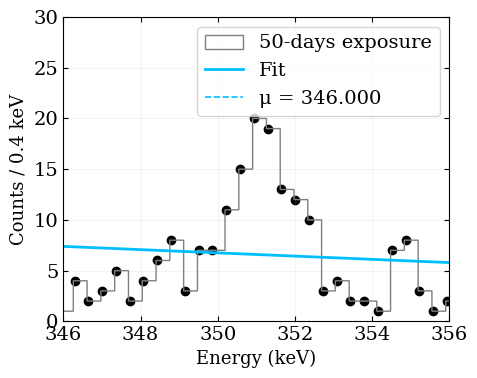

A = 0.000 -nan/+nan
mu = 346.000 -nan/+nan
sigma = 0.812 -nan/+nan
M = -0.160 -0.001/+0.128
B = 62.617 -nan/+nan


/tmp/ipykernel_133592/273796678.py:174: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


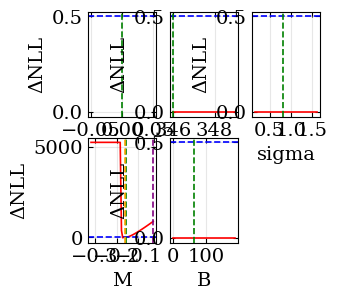

In [16]:
results = {}
picchi_bg = [ "228Ac" , "211Bi",]  # esempio: 6 picchi

peaks = [ 351]  # posizioni dei picchi da fitare (esempio)
for name,peak in zip(picchi_bg, peaks):
    fit_val, fit_err_minus, fit_err_plus, res = fit_gaussian_poisson_plot(
        E_kev, spectrum_50, center=peak, de=5
    )
    
    N, mu_fit, sigma_fit, M_fit, B_fit = fit_val
    err_N = 0.5 * (fit_err_minus[0] + fit_err_plus[0])
    
    results[name] = {
        "N": N,
        "err_N": err_N,
        "mu": mu_fit,
        "sigma": sigma_fit,
        'M': M_fit,
        "B": B_fit
    }

# picco 3

In [17]:
import pymc as pm
from scipy.stats import norm

def gaussian_pdf(E, mu, sigma):
    return 1/(sigma*np.sqrt(2*np.pi))* np.exp(-(E-mu)**2/(2*sigma**2))



sigma_signal = sigma_fun(bb_peaks[2])

roi = (E_kev > ROIs[2][0]) & (E_kev < ROIs[2][1])


E = E_kev[roi]
counts = spectrum_50[roi] 

In [18]:
mu_bg = [765]
sigma_bg = np.array([sigma_fun(mu) for mu in mu_bg])

In [19]:
PDF_bg = np.array([norm.pdf(E, mu_bg[k], sigma_bg[k]) for k in range(len(mu_bg))])
PDF_signal = norm.pdf(E, mu_signal, sigma_signal)

In [20]:
import pytensor.tensor as pt
import arviz as az
import multiprocessing

In [21]:
picchi_bg = ["BKG"]  # esempio: 6 picchi
num_picchi = len(picchi_bg)

In [22]:
with pm.Model() as model: 
    # Ampiezze background 
    for name in picchi_bg:
        A_bg[name] = pm.Uniform(f"A_{name}", lower=0, upper=1e6)
    A_signal = pm.Uniform("A_signal", lower=0, upper=1e6)
    Q = pm.Uniform("Q", lower=0, upper=1e6)
        # --- modello --- 
    A_bg_array = pt.stack([A_bg[name] for name in picchi_bg]) 
    lambda_E = ( Q  +pt.sum(A_bg_array.reshape((num_picchi, 1)) * PDF_bg, axis=0) + A_signal * PDF_signal )
    # Likelihood 
    counts_obs = pm.Poisson( "counts_obs", mu=lambda_E, observed=counts ) 
    trace = pm.sample( 250, tune=250, cores=5, chains=2, target_accept=0.9, return_inferencedata=True, progressbar=True )

NameError: name 'A_bg' is not defined

In [ ]:
az.summary(trace, round_to=4).head()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
A_BKG,261594.8609,261849.6240,4.9353,523182.5053,182920.2834,0.0747,2.6939,11.8049,2.1057
A_signal,286750.4963,287036.1759,0.3192,573499.4950,200514.8522,0.0444,2.9145,39.9264,1.8809
Q,268836.7092,306013.0060,0.7273,650715.8186,198583.6161,35197.5352,2.5845,11.2515,2.2359


<Figure size 600x400 with 0 Axes>

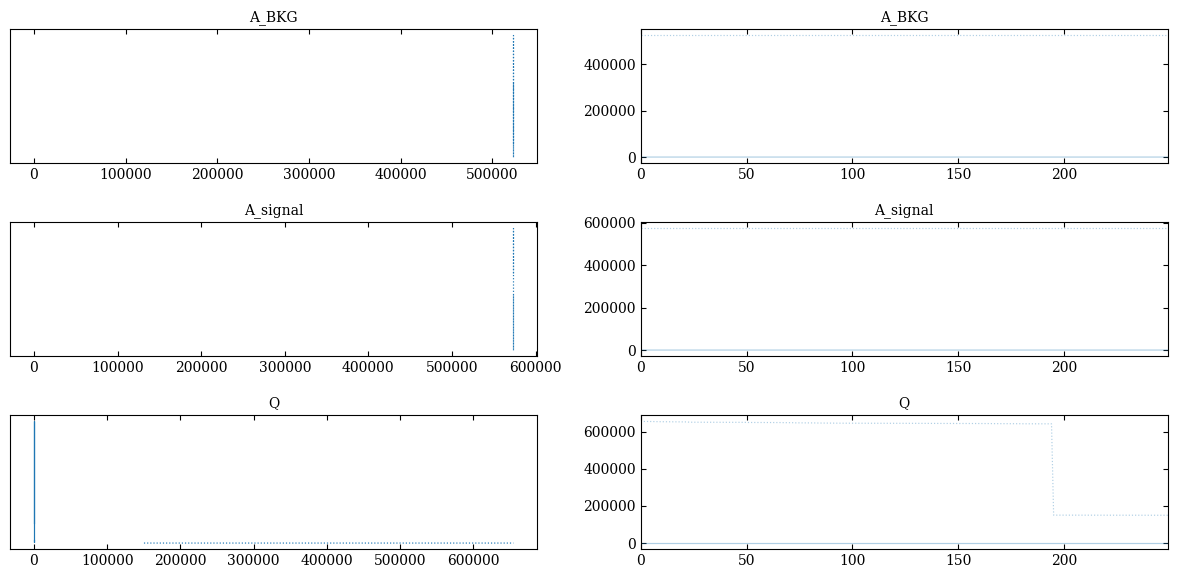

In [ ]:
plt.figure(figsize = (6,4))
axes = az.plot_trace(trace)
fig = plt.gcf()
fig.tight_layout()
plt.show()

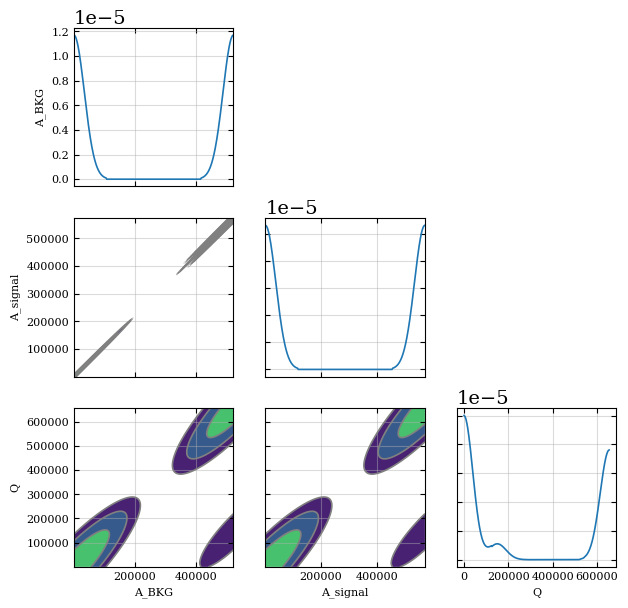

In [ ]:

axes = az.plot_pair(
    trace,
    kind="kde",
    marginals=True,
    textsize=8,
    figsize=(7, 7)
)

for ax in axes.flatten():
    ax.grid(alpha = 0.45)

plt.show()

In [ ]:
signal_samples = trace.posterior['A_signal'].values.flatten()
N_signal_90 = np.percentile(signal_samples, 90)

print("Upper limit on N_signal (90%):", N_signal_90)

Upper limit on N_signal (90%): 573499.4948287177


Upper limit on N (95%): 573499.49
Upper limit on N (90%):  573499.49
Upper limit on N (68%) : 573499.49


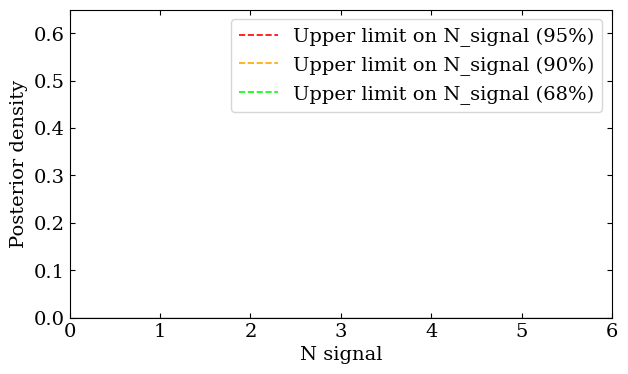

In [ ]:




plt.figure(figsize=(7,4))
plt.hist(signal_samples, bins=30, histtype='step', density=True)
plt.vlines([np.percentile(signal_samples, 95)],0, 1, ls = '--', color = 'red', label =  "Upper limit on N_signal (95%)" )
print(f"Upper limit on N (95%): { np.percentile(signal_samples, 95):.2f}")
plt.vlines([np.percentile(signal_samples, 90)],0, 1, ls = '--', color = 'orange', label =  "Upper limit on N_signal (90%)" )
print(f"Upper limit on N (90%):  {np.percentile(signal_samples, 90):.2f}")
plt.vlines([np.percentile(signal_samples, 68)],0, 1, ls = '--', color = 'lime', label =  "Upper limit on N_signal (68%)" )
print(f"Upper limit on N (68%) : {np.percentile(signal_samples, 68):.2f}")
plt.xlabel("N signal")
plt.ylabel("Posterior density")
plt.xlim(0, 6)
plt.ylim(0, 0.65)
plt.legend()
plt.show()

In [ ]:
posterior_means = {name: trace.posterior[name].mean().values for name in trace.posterior.data_vars}

print("Ampiezze medie dei picchi:")
for name, val in posterior_means.items():
    print(f"{name}: {val:.2f}")

Ampiezze medie dei picchi:
A_BKG: 261594.86
A_signal: 286750.50
Q: 268836.71


In [ ]:
# Ricostruzione lambda_E dal trace
lambda_pred = posterior_means['Q'] * np.ones_like(E)

for i, name in enumerate(picchi_bg):
    lambda_pred += posterior_means[f"A_{name}"] * PDF_bg[i]

lambda_pred += posterior_means['A_signal'] * PDF_signal

In [ ]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

In [278]:
idata = trace  # se return_inferencedata=True

idata.posterior

<xarray.Dataset> Size: 14kB
Dimensions:   (chain: 2, draw: 250)
Coordinates:
  * chain     (chain) int64 16B 0 1
  * draw      (draw) int64 2kB 0 1 2 3 4 5 6 7 ... 243 244 245 246 247 248 249
Data variables:
    A_BKG     (chain, draw) float64 4kB 7.738 5.34 10.13 ... 5.232e+05 5.232e+05
    A_signal  (chain, draw) float64 4kB 1.181 1.66 1.511 ... 5.735e+05 5.735e+05
    Q         (chain, draw) float64 4kB 0.9297 0.9796 ... 1.497e+05 1.497e+05
Attributes:
    created_at:                 2026-05-08T13:23:43.166604+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.26.1
    sampling_time:              119.71558928489685
    tuning_steps:               250

C:\Users\rirri\AppData\Local\Temp\ipykernel_29040\3780208949.py:92: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(0, 13)


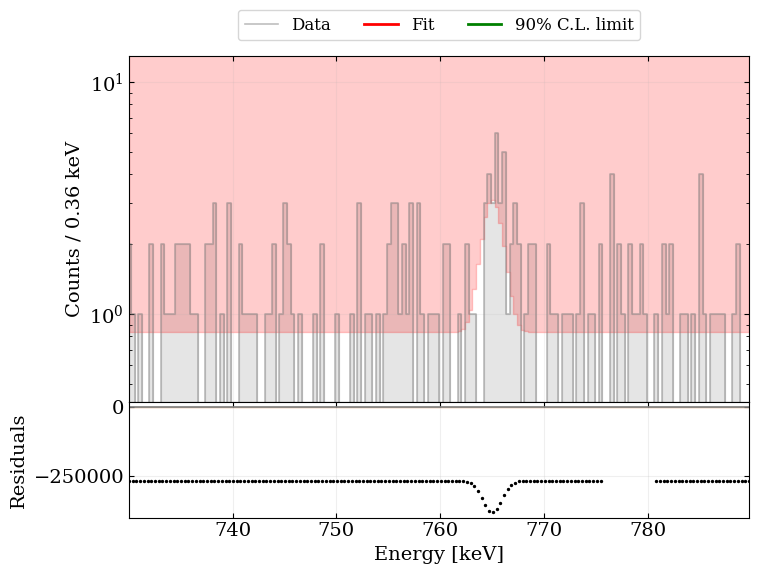

In [279]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# FIGURA CON 2 SUBPLOT
# =========================
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    figsize=(8, 6)
)

# =========================
# POSTERIOR FLATTENING
# =========================
posterior = idata.posterior

Q_s = posterior["Q"].values.reshape(-1)
A_signal_s = posterior["A_signal"].values.reshape(-1)

A_bg_s = {}
for name in picchi_bg:
    A_bg_s[name] = posterior[f"A_{name}"].values.reshape(-1)

# =========================
# λ(E) PER OGNI SAMPLE
# =========================
lambda_samples = []
lambda_bkg = []
for i in range(len(Q_s)):
    lam = Q_s[i] * np.ones_like(E)
    lam_bk = Q_s[i] * np.ones_like(E)

    for j, name in enumerate(picchi_bg):
        lam += A_bg_s[name][i] * PDF_bg[j]
        lam_bk += A_bg_s[name][i] * PDF_bg[j]

    lam += A_signal_s[i] * PDF_signal
    
    lambda_samples.append(lam)
    lambda_bkg.append(lam_bk)

lambda_samples = np.array(lambda_samples)
lambda_bkg  = np.array(lambda_bkg)
# =========================
# RESIDUI
# =========================
window = 2.5
E0 = bb_peaks[2]
mask = (E < E0 - window) | (E > E0 + window)

lambda_mean = np.mean(lambda_samples, axis=0)

residuals = counts - lambda_mean

# =========================
# BASELINE + FIT
# =========================
B_array = posterior_means['Q'] * np.ones_like(E)

lambda_pred_bkg = B_array.copy()
for i, name in enumerate(picchi_bg):
    lambda_pred_bkg += posterior_means[f"A_{name}"] * PDF_bg[i]

lambda_pred = lambda_pred_bkg + N_signal_90 * PDF_signal
lambda_low = np.percentile(lambda_bkg, 5, axis=0)
lambda_high = np.percentile(lambda_bkg, 95, axis=0)
# =========================
# PLOT SUPERIORE (SPETTRO)
# =========================
ax1.step(E, counts, where='mid', alpha=0.5, color='grey', label='Data')
ax1.fill_between(E, counts, color='grey', step='mid', alpha=0.2)

ax1.plot(E, lambda_pred_bkg, color='red', lw=2, zorder = 10, label='Fit')
ax1.plot(E, lambda_pred, color='green', lw=2, zorder = 5,label='90% C.L. limit')

ax1.fill_between(E, lambda_low, lambda_high,
                 color='red', alpha=0.2, step='mid')

ax1.vlines(871, 0, 20, ls='--', color='black', alpha=0.75)

ax1.annotate(
    "871.1 keV",
    xy=(871.1 - 3, 5),
    rotation=90,
    fontsize=11
)

ax1.set_yscale('log')
ax1.set_ylabel("Counts / 0.36 keV")
ax1.set_ylim(0, 13)
ax1.grid(alpha=0.15)

ax1.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    fontsize=12
)

# niente ticks sopra
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# =========================
# PLOT INFERIORE (RESIDUI)
# =========================
ax2.scatter(E[mask], residuals[mask], s = 2, color='black', zorder=10)

ax2.axhspan(-3, 3, color='red', alpha=0.25)
ax2.axhspan(-2, 2, color='orange', alpha=0.2)
ax2.axhspan(-1, 1, color='green', alpha=0.15)

ax2.axhline(0, color='gray')

ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Residuals")
ax2.grid(alpha=0.2)

plt.xlim(min(E), max(E))

# =========================
# SPAZIO ZERO TRA I PLOT
# =========================
plt.subplots_adjust(hspace=0)

plt.show()

In [ ]:

# Dati campione
m_sample = 551.3        # massa ZrO2 in grammi
Mr_sample = 123.22      # massa molare ZrO2 [g/mol]
N_A = 6.022e23          # numero di Avogadro
eff_94Zr = 0.022935    # efficienza di rivelazione
i_a_94Zr = 0.1738       # abbondanza isotopica
t_live = t_tot/(60*60*24*365)            # 50 giorni in anni


expo = m_sample * t_live
eff = 0.024131

# Posterior del numero di eventi segnale
signal_samples = trace.posterior['A_signal'].values.flatten()


'''
ATTENZIONE: QUI POSSIAMO METTERE IL LIMITE AL TEMPO DI DIMEZZAMENTO MA SE VOGLIAMOù
QUELLO DEL SINGOLO CANALE DEVO ANCHE ACCEDERE AGLI ALTRI CANALI.
'''

# Numero di nuclei 96Zr nel campione
N_nuclei = (m_sample * i_a_94Zr / Mr_sample) * N_A

percentile = 90

T_half_limit = (np.log(2) * N_nuclei * eff_94Zr * t_live) / np.percentile(signal_samples, percentile)
print(f"T1/2 > {T_half_limit:.2e} yrs at {percentile}%")

T1/2 > 1.76e+15 yrs at 90%


# picco 2

In [256]:
#